In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [29]:
pd.set_option("display.max_columns", None)


In [30]:
sns.set_style("whitegrid")

In [31]:
df = pd.read_csv("credit_risk_dataset.csv")

In [32]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [33]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [34]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [35]:
df["loan_intent"].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [36]:
df["loan_grade_category"] = df["loan_grade"].map({
    "A": "Low Risk",
    "B": "Low Risk",
    "C": "Medium Risk",
    "D": "Medium Risk",
    "E": "High Risk",
    "F": "High Risk",
    "G": "High Risk"
})

In [37]:
df["loan_grade_category"].unique()

array(['Medium Risk', 'Low Risk', 'High Risk'], dtype=object)

In [38]:
df["loan_int_rate"].describe()

count    29465.000000
mean        11.011695
std          3.240459
min          5.420000
25%          7.900000
50%         10.990000
75%         13.470000
max         23.220000
Name: loan_int_rate, dtype: float64

In [39]:
grade_map = {
    "A": 5,
    "B": 4,
    "C": 3,
    "D": 2,
    "E": 1
}

df["loan_grade_score"] = df["loan_grade"].map(grade_map)

In [40]:
df["loan_grade_score"].unique()

array([ 2.,  4.,  3.,  5.,  1., nan])

In [41]:
df["loan_grade_score"].describe()

count    32276.000000
mean         3.819525
std          1.104371
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: loan_grade_score, dtype: float64

In [42]:
df["loan_amnt"].describe()

count    32581.000000
mean      9589.371106
std       6322.086646
min        500.000000
25%       5000.000000
50%       8000.000000
75%      12200.000000
max      35000.000000
Name: loan_amnt, dtype: float64

In [43]:
df["loan_amnt"].value_counts()

loan_amnt
10000    2664
5000     2043
12000    1809
6000     1801
15000    1502
         ... 
15575       1
19275       1
10325       1
13025       1
14775       1
Name: count, Length: 753, dtype: int64

In [44]:
df["loan_grade"].unique()

array(['D', 'B', 'C', 'A', 'E', 'F', 'G'], dtype=object)

In [45]:
# Check unique grades
print("Unique loan grades:", df["loan_grade"].unique())

Unique loan grades: ['D' 'B' 'C' 'A' 'E' 'F' 'G']


In [46]:
print("\nGrade Distribution:")
print(df["loan_grade"].value_counts().sort_index())


Grade Distribution:
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64


In [47]:
if "loan_status" in df.columns:
    print("\nLoan Grade vs Loan Status:")
    print(pd.crosstab(df["loan_grade"], df["loan_status"], normalize="index"))


Loan Grade vs Loan Status:
loan_status         0         1
loan_grade                     
A            0.900436  0.099564
B            0.837240  0.162760
C            0.792660  0.207340
D            0.409542  0.590458
E            0.355809  0.644191
F            0.294606  0.705394
G            0.015625  0.984375


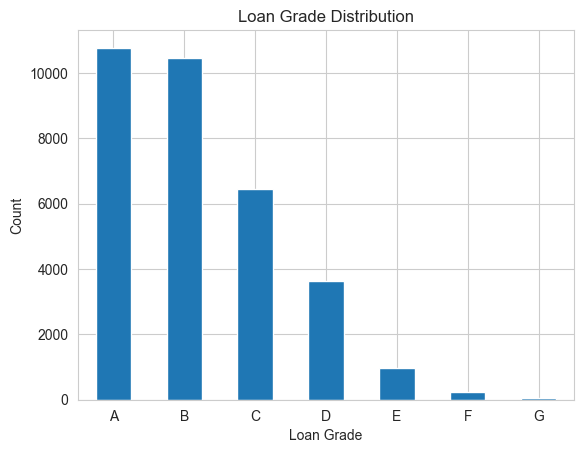

In [48]:
import matplotlib.pyplot as plt

df["loan_grade"].value_counts().sort_index().plot(kind="bar")
plt.title("Loan Grade Distribution")
plt.xlabel("Loan Grade")
plt.ylabel("Count")
plt.xticks( rotation = 0)
plt.show()

In [49]:
df["person_home_ownership"].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [50]:
df["person_age"].unique()

array([ 22,  21,  25,  23,  24,  26, 144, 123,  20,  32,  34,  29,  33,
        28,  35,  31,  27,  30,  36,  40,  50,  45,  37,  39,  44,  43,
        41,  46,  38,  47,  42,  48,  49,  58,  65,  51,  53,  66,  61,
        54,  57,  59,  62,  60,  55,  52,  64,  70,  78,  69,  56,  73,
        63,  94,  80,  84,  76,  67])

In [51]:
df["person_income"].unique()

array([  59000,    9600,   65500, ...,  720000, 1900000,    4888],
      shape=(4295,))

In [52]:
df["person_emp_length"].unique()

array([123.,   5.,   1.,   4.,   8.,   2.,   6.,   7.,   0.,   9.,   3.,
        10.,  nan,  11.,  18.,  12.,  17.,  14.,  16.,  13.,  19.,  15.,
        20.,  22.,  21.,  24.,  23.,  26.,  25.,  27.,  28.,  31.,  41.,
        34.,  29.,  38.,  30.])

In [53]:
df["loan_amnt"].unique()

array([35000,  1000,  5500,  2500,  1600,  4500, 30000,  1750, 34800,
       34000,  1500, 33950, 33000,  4575,  1400, 32500,  4000,  2000,
       32000, 31050, 24250,  7800, 20000, 10000, 25000, 18000, 12000,
       29100, 28000,  9600,  3000,  6100,  4200,  4750,  4800,  2700,
       27600,  3250, 27500, 27050, 27000, 26000, 25600, 25475, 21600,
       11900, 25300,  3650,  6000,  2400,  3600,  7500,  4950, 21000,
       16000, 22000,  7750, 24000, 15000, 15500,  9000, 23050,  5375,
        6250,  5000,  2100, 14000,  6200,  9950,  4475,  2600,  8000,
        4600,  3500,  7200,  8800,  3175,  2800, 13000,  1800,  3300,
        3200,  2275,  5600,  3625,  4375, 24750, 24500,  3900, 13750,
       15250, 24150,  2250,  4975,  4900, 23975, 23750, 23600, 23575,
        5400,  3375, 23400, 23000,  1200, 22750, 22500, 22400, 22250,
        7400, 21700,  7000, 21500, 21450, 21250,  9250, 20900, 20500,
       20400, 20375, 20050,  6400,  5650, 16600,  7125,  3550,  1275,
        3800,  1625,

In [54]:
df["loan_int_rate"].unique()

array([16.02, 11.14, 12.87, 15.23, 14.27,  7.14, 12.42, 11.11,  8.9 ,
       14.74, 10.37,  8.63,  7.9 , 18.39, 10.65, 20.25, 18.25, 10.99,
        7.49, 16.77, 17.58,  7.29, 14.54, 12.68, 17.74,  9.32,  9.99,
       12.84, 11.12,  6.62, 14.17, 13.85, 13.49,  7.51, 16.89,   nan,
       17.99, 12.69,  7.88, 19.41, 10.38, 15.33, 16.45, 18.62, 15.96,
       11.48,  5.99, 11.58, 15.7 , 15.99, 14.84, 14.42,  6.99, 13.61,
        9.91, 13.48, 12.98, 13.57, 15.68, 13.06, 15.62, 11.71,  8.88,
       12.18, 13.99,  5.42, 12.73, 11.49, 19.91, 11.83, 14.59,  9.64,
       16.35, 18.67, 10.08, 10.36, 12.23, 16.07, 14.22, 14.79, 13.22,
       11.86, 13.43, 15.28, 17.93,  9.25, 10.62, 18.43, 11.36, 15.65,
       13.04, 17.04, 14.83, 14.65, 16.82, 10.25, 14.96, 11.99,  8.49,
        6.17, 16.32, 14.35, 15.21, 14.09, 17.49, 13.92, 16.49,  5.79,
       13.11,  6.54, 12.53, 15.95, 10.74, 15.27, 14.72, 13.35,  7.68,
       14.46, 13.47,  6.03, 12.92, 18.64, 16.7 , 18.3 ,  9.63, 14.7 ,
       15.37, 14.26,

In [55]:
df["loan_status"].unique()

array([1, 0])

In [56]:
df["loan_percent_income"].unique()

array([0.59, 0.1 , 0.57, 0.53, 0.55, 0.25, 0.45, 0.44, 0.42, 0.16, 0.41,
       0.37, 0.32, 0.3 , 0.06, 0.29, 0.31, 0.22, 0.52, 0.14, 0.49, 0.13,
       0.5 , 0.35, 0.17, 0.27, 0.33, 0.08, 0.03, 0.21, 0.63, 0.47, 0.4 ,
       0.07, 0.38, 0.34, 0.04, 0.23, 0.15, 0.11, 0.43, 0.51, 0.02, 0.28,
       0.26, 0.19, 0.39, 0.09, 0.05, 0.61, 0.18, 0.6 , 0.01, 0.48, 0.12,
       0.54, 0.56, 0.46, 0.36, 0.24, 0.2 , 0.72, 0.64, 0.69, 0.77, 0.83,
       0.65, 0.67, 0.58, 0.71, 0.68, 0.7 , 0.66, 0.  , 0.76, 0.62, 0.78])

In [57]:
df["loan_percent_income"].describe()

count    32581.000000
mean         0.170203
std          0.106782
min          0.000000
25%          0.090000
50%          0.150000
75%          0.230000
max          0.830000
Name: loan_percent_income, dtype: float64

In [58]:
df["cb_person_cred_hist_length"].unique()

array([ 3,  2,  4,  8,  7,  6,  9, 10,  5, 11, 16, 15, 12, 13, 17, 14, 25,
       28, 27, 22, 19, 29, 23, 26, 20, 21, 30, 24, 18])

In [59]:
df["cb_person_cred_hist_length"].describe()

count    32581.000000
mean         5.804211
std          4.055001
min          2.000000
25%          3.000000
50%          4.000000
75%          8.000000
max         30.000000
Name: cb_person_cred_hist_length, dtype: float64

In [60]:
df["cb_person_default_on_file"].unique()

array(['Y', 'N'], dtype=object)

In [61]:
df["cb_person_default_on_file"].describe()

count     32581
unique        2
top           N
freq      26836
Name: cb_person_default_on_file, dtype: object

In [62]:
print("Shape:", df.shape)
df.info()


Shape: (32581, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
 12  loan_grade_category         32581 non-null  object 
 13  loan_grade_s

In [63]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]


loan_int_rate        3116
person_emp_length     895
loan_grade_score      305
dtype: int64

In [64]:
# Duplicates
print("Duplicates:", df.duplicated().sum())


Duplicates: 165


In [65]:
# Example: replace 'loan_id' with actual ID column
if "loan_id" in df.columns:
    duplicate_count = df.duplicated(subset="loan_id").sum()
    print("Duplicate loan_id records:", duplicate_count)


In [66]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (32416, 14)


In [67]:
missing_summary = (
    df.isnull()
      .sum()
      .to_frame("Missing_Count")
)

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Count"] / len(df) * 100
)

missing_summary = missing_summary[missing_summary["Missing_Count"] > 0]
missing_summary.sort_values("Missing_Percentage", ascending=False)


,Missing_Count,Missing_Percentage
loan_int_rate,3095,9.547754
person_emp_length,887,2.736303
loan_grade_score,305,0.940893


In [68]:
threshold = 0.40

cols_to_drop = missing_summary[
    missing_summary["Missing_Percentage"] > threshold * 100
].index.tolist()

print("Dropping columns:", cols_to_drop)

df = df.drop(columns=cols_to_drop)



Dropping columns: []


In [69]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns


In [70]:
for col in missing_summary.index:
    df[col + "_missing_flag"] = df[col].isnull().astype(int)


In [71]:
print("Remaining missing values:")
print(df.isnull().sum().sum())

print("Final dataset shape:", df.shape)


Remaining missing values:
4287
Final dataset shape: (32416, 17)


In [72]:
df.to_csv("credit_risk_cleaned.csv", index=False)


In [73]:

invalid_conditions = pd.Series(False, index=df.index)

# Age
if "age" in df.columns:
    invalid_conditions |= (df["age"] < 18) | (df["age"] > 100)

# Annual Income
if "annual_income" in df.columns:
    invalid_conditions |= df["annual_income"] <= 0

# Loan Amount
if "loan_amount" in df.columns:
    invalid_conditions |= df["loan_amount"] <= 0

# Loan-to-Income sanity
if {"loan_amount", "annual_income"}.issubset(df.columns):
    invalid_conditions |= df["loan_amount"] > 10 * df["annual_income"]

# Credit Score
if "credit_score" in df.columns:
    invalid_conditions |= (df["credit_score"] < 300) | (df["credit_score"] > 900)

# Employment Length
if "employment_length" in df.columns:
    invalid_conditions |= df["employment_length"] < 0

# Debt-to-Income Ratio
if "dti" in df.columns:
    invalid_conditions |= (df["dti"] < 0) | (df["dti"] > 1)

# Interest Rate
if "interest_rate" in df.columns:
    invalid_conditions |= (df["interest_rate"] <= 0) | (df["interest_rate"] > 0.60)

# Number of Defaults
if "num_defaults" in df.columns:
    invalid_conditions |= df["num_defaults"] < 0

# Loan Term
if "loan_term" in df.columns:
    invalid_conditions |= ~df["loan_term"].isin([12, 24, 36, 60])


In [74]:
invalid_count = invalid_conditions.sum()
print(f"Invalid rows detected: {invalid_count}")
print(f"Percentage removed: {invalid_count / len(df) * 100:.2f}%")


Invalid rows detected: 0
Percentage removed: 0.00%


In [75]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'loan_grade_category', 'loan_grade_score',
       'person_emp_length_missing_flag', 'loan_int_rate_missing_flag',
       'loan_grade_score_missing_flag'],
      dtype='object')

In [76]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_grade_category,loan_grade_score,person_emp_length_missing_flag,loan_int_rate_missing_flag,loan_grade_score_missing_flag
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,Medium Risk,2.0,0,0,0
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,Low Risk,4.0,0,0,0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,Medium Risk,3.0,0,0,0
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,Medium Risk,3.0,0,0,0
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,Medium Risk,3.0,0,0,0


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32416 entries, 0 to 32580
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      32416 non-null  int64  
 1   person_income                   32416 non-null  int64  
 2   person_home_ownership           32416 non-null  object 
 3   person_emp_length               31529 non-null  float64
 4   loan_intent                     32416 non-null  object 
 5   loan_grade                      32416 non-null  object 
 6   loan_amnt                       32416 non-null  int64  
 7   loan_int_rate                   29321 non-null  float64
 8   loan_status                     32416 non-null  int64  
 9   loan_percent_income             32416 non-null  float64
 10  cb_person_default_on_file       32416 non-null  object 
 11  cb_person_cred_hist_length      32416 non-null  int64  
 12  loan_grade_category             32416

In [78]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'loan_grade_category', 'loan_grade_score',
       'person_emp_length_missing_flag', 'loan_int_rate_missing_flag',
       'loan_grade_score_missing_flag'],
      dtype='object')

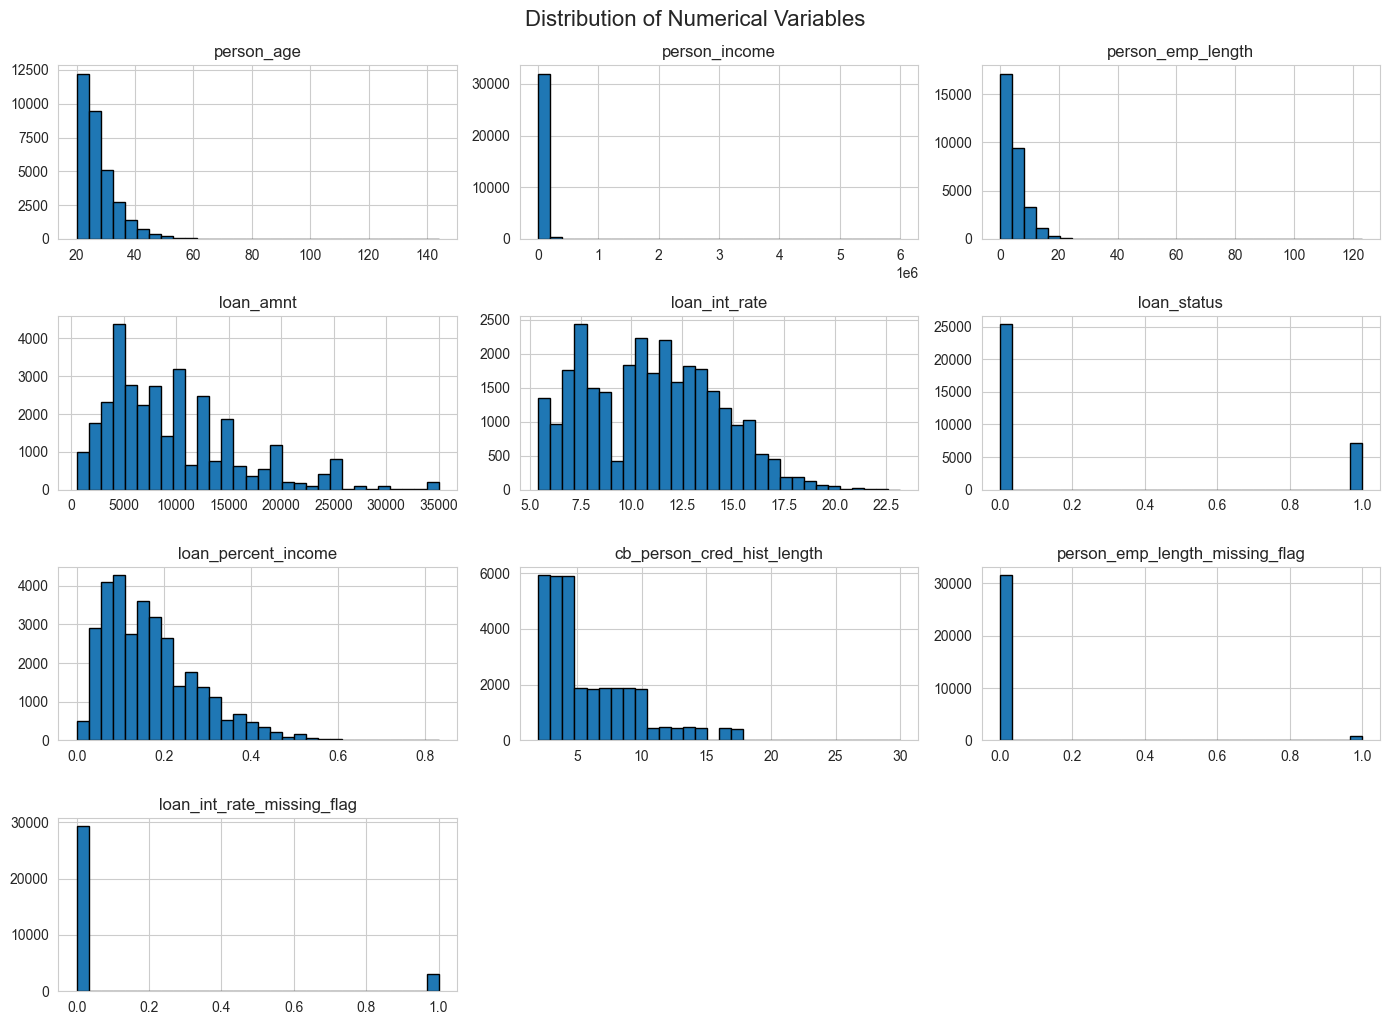

In [79]:

num_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_status',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'person_emp_length_missing_flag',
    'loan_int_rate_missing_flag'
]


df[num_cols].hist(
    bins=30,
    figsize=(14, 10),
    edgecolor='black'
)

# fix overlapping titles & spacing
plt.tight_layout()
plt.suptitle("Distribution of Numerical Variables", fontsize=16, y=1.02)

plt.show()



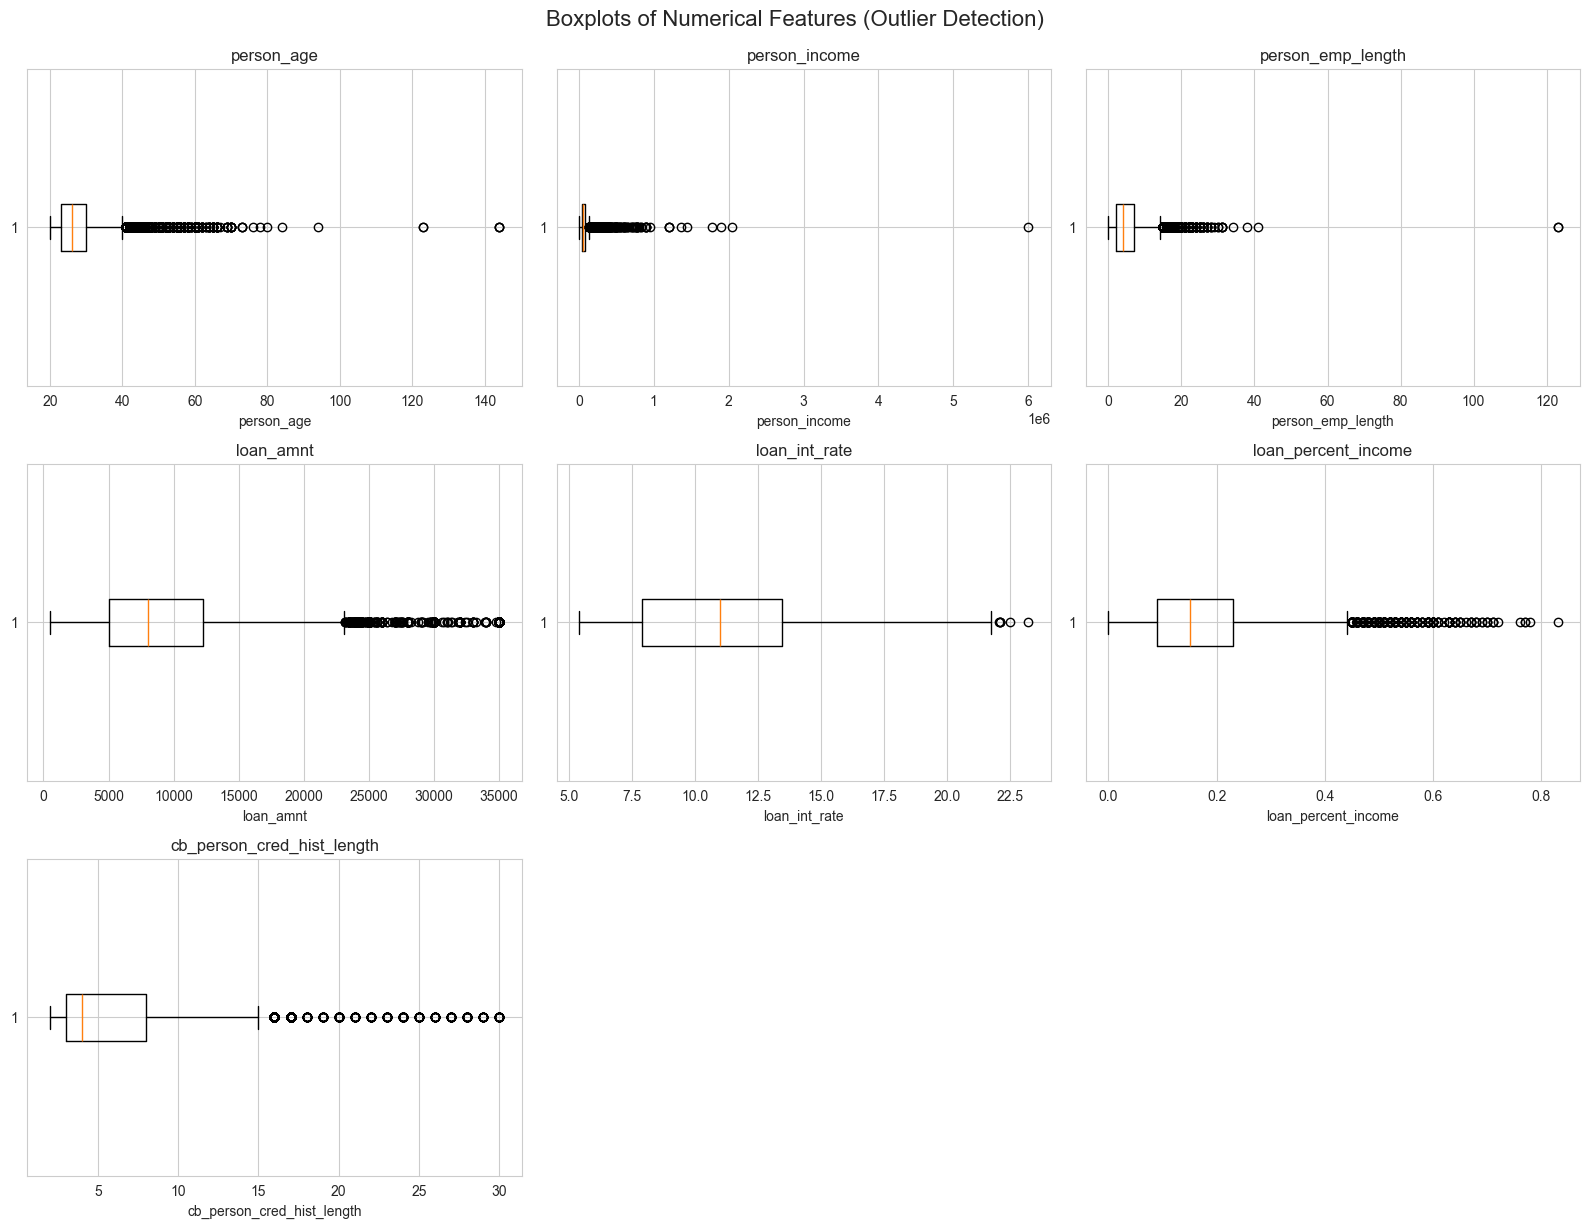

In [80]:

num_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

# create subplots
plt.figure(figsize=(16, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
    plt.xlabel(col)

plt.tight_layout()
plt.suptitle("Boxplots of Numerical Features (Outlier Detection)", fontsize=16, y=1.02)
plt.show()


In [81]:
def cap_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

iqr_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

for col in iqr_cols:
    df[col] = cap_outliers_iqr(df[col])


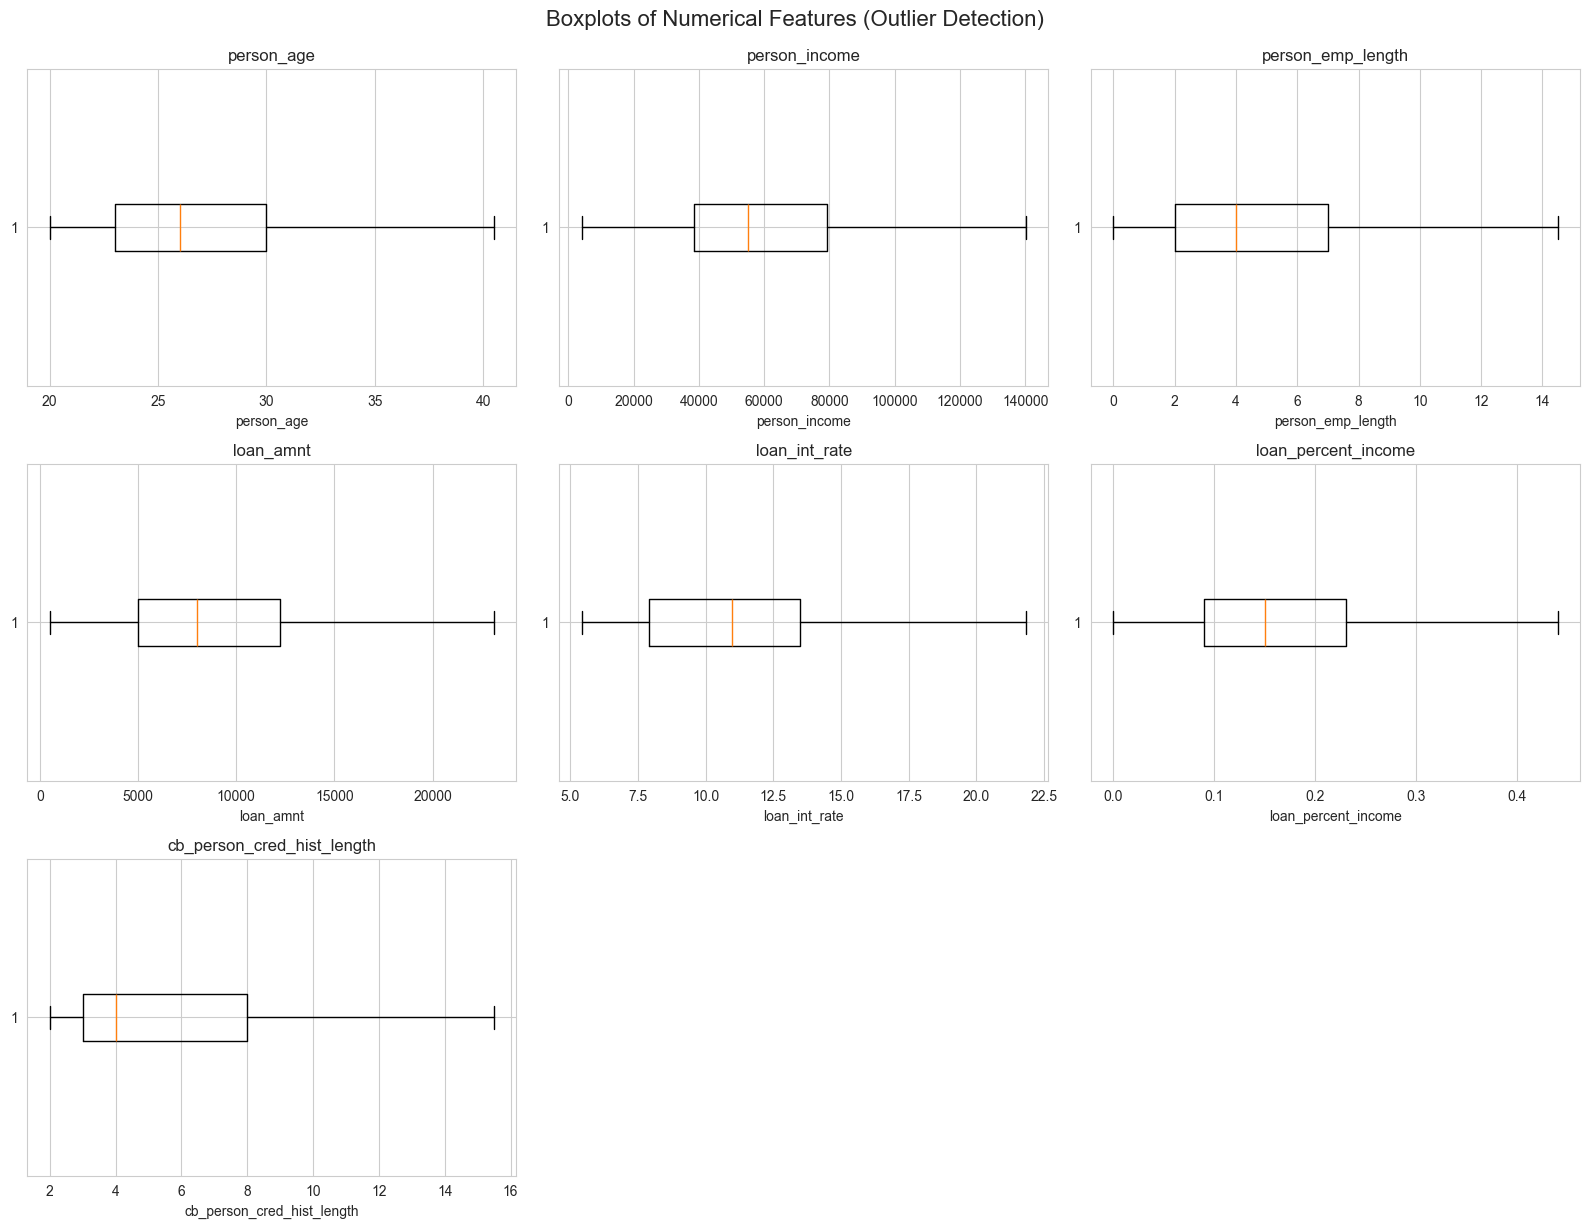

In [82]:
num_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

# create subplots
plt.figure(figsize=(16, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
    plt.xlabel(col)

plt.tight_layout()
plt.suptitle("Boxplots of Numerical Features (Outlier Detection)", fontsize=16, y=1.02)
plt.show()


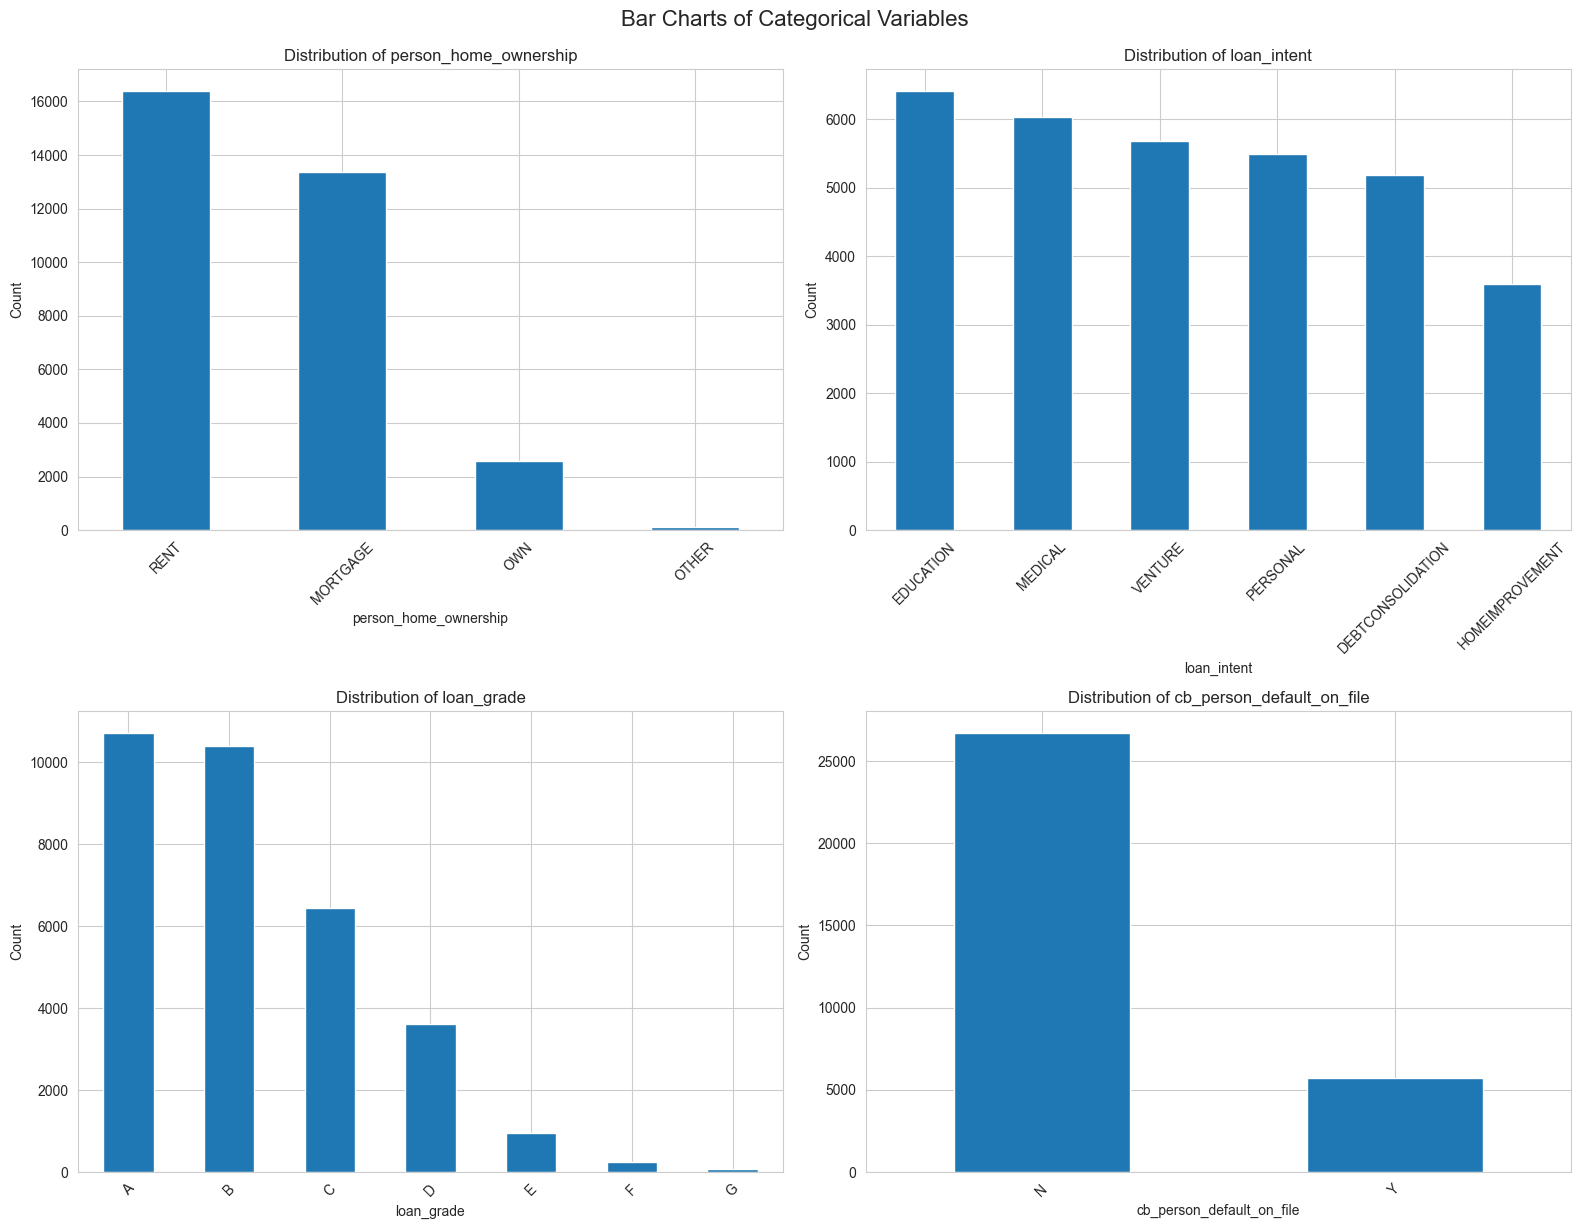

In [83]:

cat_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

plt.figure(figsize=(16, 12))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle("Bar Charts of Categorical Variables", fontsize=16, y=1.02)
plt.show()


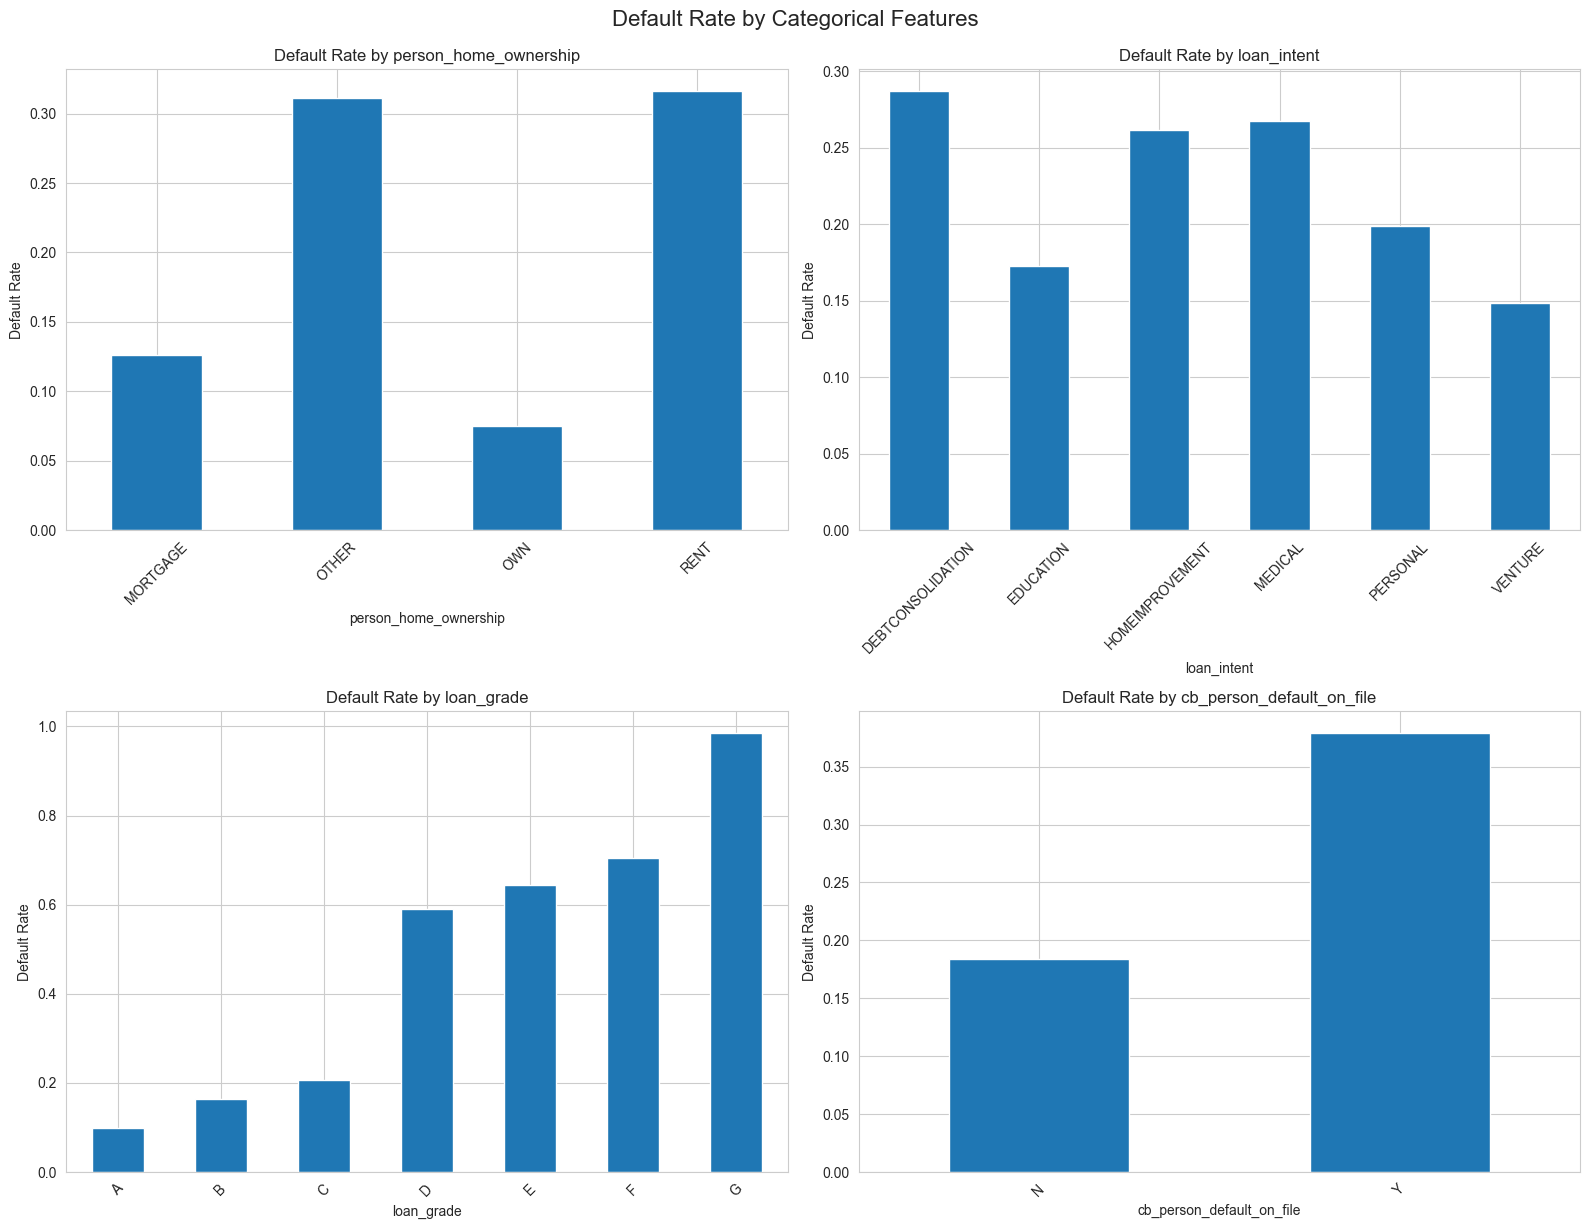

In [84]:
# Risk of default per category 

plt.figure(figsize=(16, 12))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    default_rate = df.groupby(col)['loan_status'].mean()
    default_rate.plot(kind='bar')
    plt.title(f'Default Rate by {col}')
    plt.ylabel('Default Rate')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle("Default Rate by Categorical Features", fontsize=16, y=1.02)
plt.show()


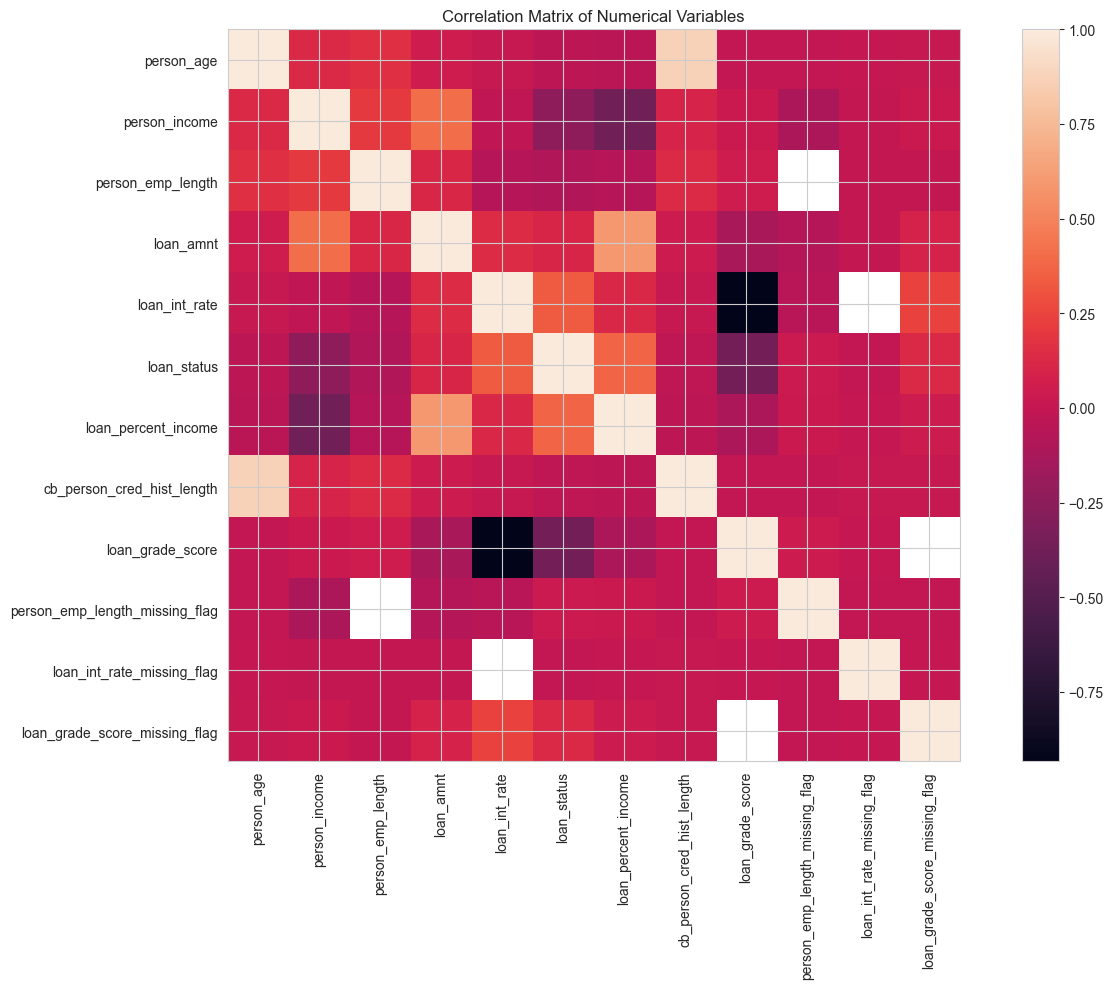

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# select numerical columns only
num_df = df.select_dtypes(include=['int64', 'float64'])

# compute correlation
corr_matrix = num_df.corr()

# plot heatmap
plt.figure(figsize=(14, 10))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


In [86]:
#Correlation with target only
corr_target = num_df.corr()['loan_status'].sort_values(ascending=False)

print(corr_target)


loan_status                       1.000000
loan_percent_income               0.378183
loan_int_rate                     0.335835
loan_grade_score_missing_flag     0.128555
loan_amnt                         0.104994
person_emp_length_missing_flag    0.039810
loan_int_rate_missing_flag       -0.009102
cb_person_cred_hist_length       -0.019917
person_age                       -0.027306
person_emp_length                -0.090615
person_income                    -0.246134
loan_grade_score                 -0.354630
Name: loan_status, dtype: float64


In [87]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'loan_grade_category', 'loan_grade_score',
       'person_emp_length_missing_flag', 'loan_int_rate_missing_flag',
       'loan_grade_score_missing_flag'],
      dtype='object')

In [88]:
df.groupby('person_age')["loan_status"].mean()

person_age
20.0    0.133333
21.0    0.305029
22.0    0.244525
23.0    0.215488
24.0    0.217527
25.0    0.222957
26.0    0.209586
27.0    0.208275
28.0    0.222403
29.0    0.203329
30.0    0.197710
31.0    0.205443
32.0    0.199792
33.0    0.202339
34.0    0.196328
35.0    0.206785
36.0    0.224863
37.0    0.202929
38.0    0.166220
39.0    0.229236
40.0    0.207407
40.5    0.213280
Name: loan_status, dtype: float64

In [89]:
df.groupby('person_income')["loan_status"].mean()

person_income
4000      1.000000
4080      1.000000
4200      1.000000
4800      1.000000
4888      1.000000
            ...   
139913    0.000000
139992    0.000000
140000    0.000000
140004    0.142857
140232    0.097429
Name: loan_status, Length: 3935, dtype: float64

In [90]:
df.groupby('person_emp_length')["loan_status"].mean()

person_emp_length
0.0     0.279736
1.0     0.277183
2.0     0.257568
3.0     0.201917
4.0     0.212365
5.0     0.187286
6.0     0.187783
7.0     0.188015
8.0     0.167064
9.0     0.178808
10.0    0.170520
11.0    0.183673
12.0    0.155867
13.0    0.119718
14.0    0.167665
14.5    0.167840
Name: loan_status, dtype: float64

In [91]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'loan_grade_category', 'loan_grade_score',
       'person_emp_length_missing_flag', 'loan_int_rate_missing_flag',
       'loan_grade_score_missing_flag'],
      dtype='object')

In [92]:
features = ['person_age', 'person_income', 'person_home_ownership',
            'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
            'loan_int_rate', 'loan_percent_income','cb_person_default_on_file', 
            'cb_person_cred_hist_length',
            'person_emp_length_missing_flag', 'loan_int_rate_missing_flag']

In [93]:
target = ['loan_status']

In [94]:
df_model = df[features + (target)].copy()

In [95]:
df_model.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_emp_length_missing_flag,loan_int_rate_missing_flag,loan_status
0,22.0,59000,RENT,14.5,PERSONAL,D,23125,16.02,0.44,Y,3.0,0,0,1
1,21.0,9600,OWN,5.0,EDUCATION,B,1000,11.14,0.10,N,2.0,0,0,0
2,25.0,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.44,N,3.0,0,0,1
3,23.0,65500,RENT,4.0,MEDICAL,C,23125,15.23,0.44,N,2.0,0,0,1
4,24.0,54400,RENT,8.0,MEDICAL,C,23125,14.27,0.44,Y,4.0,0,0,1


In [96]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [97]:
cat_cols = (
    df_model
    .select_dtypes(include='object')
    .columns
    .drop('loan_status', errors = 'ignore')
)


In [98]:
le_dict = {}

In [99]:
cat_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

In [100]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump( le, f"{col}_encoder.pkl")

In [101]:
le_target = LabelEncoder()

In [102]:
target

['loan_status']

In [103]:
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()

target = 'loan_status'   

df_model[target] = le_target.fit_transform(df_model[target])


In [104]:
df_model[target]

0        1
1        0
2        1
3        1
4        1
        ..
32576    0
32577    0
32578    1
32579    0
32580    0
Name: loan_status, Length: 32416, dtype: int64

In [105]:
df_model[target].value_counts()

loan_status
0    25327
1     7089
Name: count, dtype: int64

In [106]:
joblib.dump( le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [107]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Create encoder
loan_grade_category_encoder = LabelEncoder()

# Fit encoder
df["loan_grade_category"] = loan_grade_category_encoder.fit_transform(
    df["loan_grade_category"]
)

# Save encoder
joblib.dump(loan_grade_category_encoder, "loan_grade_category_encoder.pkl")

['loan_grade_category_encoder.pkl']

In [108]:
df_model.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_emp_length_missing_flag,loan_int_rate_missing_flag,loan_status
0,22.0,59000,3,14.5,4,3,23125,16.02,0.44,1,3.0,0,0,1
1,21.0,9600,2,5.0,1,1,1000,11.14,0.10,0,2.0,0,0,0
2,25.0,9600,0,1.0,3,2,5500,12.87,0.44,0,3.0,0,0,1
3,23.0,65500,3,4.0,3,2,23125,15.23,0.44,0,2.0,0,0,1
4,24.0,54400,3,8.0,3,2,23125,14.27,0.44,1,4.0,0,0,1


In [109]:
from sklearn.model_selection import train_test_split

In [110]:
x = df_model.drop(target, axis = 1)

In [111]:
y = df_model[target]

In [112]:
x

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_emp_length_missing_flag,loan_int_rate_missing_flag
0,22.0,59000,3,14.5,4,3,23125,16.02,0.44,1,3.0,0,0
1,21.0,9600,2,5.0,1,1,1000,11.14,0.10,0,2.0,0,0
2,25.0,9600,0,1.0,3,2,5500,12.87,0.44,0,3.0,0,0
3,23.0,65500,3,4.0,3,2,23125,15.23,0.44,0,2.0,0,0
4,24.0,54400,3,8.0,3,2,23125,14.27,0.44,1,4.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,40.5,53000,0,1.0,4,2,5800,13.16,0.11,0,15.5,0,0
32577,40.5,120000,0,4.0,4,0,17625,7.49,0.15,0,15.5,0,0
32578,40.5,76000,3,3.0,2,1,23125,10.99,0.44,0,15.5,0,0
32579,40.5,140232,0,5.0,4,1,15000,11.48,0.10,0,15.5,0,0


In [113]:
target

'loan_status'

In [114]:
y

0        1
1        0
2        1
3        1
4        1
        ..
32576    0
32577    0
32578    1
32579    0
32580    0
Name: loan_status, Length: 32416, dtype: int64

In [115]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=1)

In [116]:
x_train.shape

(25932, 13)

In [117]:
x_test.shape

(6484, 13)

In [124]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [125]:
def train_model(model, param_grid, x_train, y_train, x_test, y_test):
    grid = GridSearchCV(model, param_grid, cv = 5, scoring = "accuracy", n_jobs = -1)
    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [126]:
dt = DecisionTreeClassifier(random_state = 1, class_weight = "balanced")
dt_param_grid = {
    "max_depth": [3,5,7,10, None] ,
    "min_samples_split": [2,5,10] ,
    "min_samples_leaf" : [1,2,4]
}


In [127]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, x_train, y_train, x_test, y_test)

In [128]:
print("Decision Tree Accuracy", acc_dt)

Decision Tree Accuracy 0.8943553362122146


In [129]:
print("best parameters", params_dt)

best parameters {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [130]:
rf = RandomForestClassifier(random_state = 1, class_weight = "balanced", n_jobs = -1)

In [131]:
rf_param_grid = {
    "n_estimators": [100,200],
    "max_depth" : [5,7,10, None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : [1,2,4]

}

In [132]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, x_train, y_train, x_test, y_test)

In [133]:
print("Random Forest Accuracy", acc_rf)

Random Forest Accuracy 0.9298272671190623


In [134]:
print("Best params", params_rf)

Best params {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [135]:
best_rf.predict(x_test)

array([0, 0, 0, ..., 0, 0, 1], shape=(6484,))

In [136]:
joblib.dump(best_rf, "random_forest_credit_model.pkl")

['random_forest_credit_model.pkl']